# Data Exploration

Training data is the historical dat I'm training on (cross-validation) and the actual temperature will be the testing data to test how effective the model is at predicting temperature. X is all the other factors, y is the temperature.

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def csv_read(filepath):
    """import csv file"""
    df = pd.read_csv(filepath)

    return df


Getting the X_train data

In [114]:
historical_preds = csv_read("/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/data/raw/NOAA_GFS_FORECAST_HISTORICAL.csv")
print(historical_preds.columns)
historical_preds.head()
historical_preds.info()

cols = ['forecast_date', 'forecast_hour', 'predicted_date_time', 'forecasted_temp', 'forecast_lat', 'forecast_long']
historical_preds.columns = cols
historical_preds.head()

# Convert to datetime
historical_preds['forecast_date'] = pd.to_datetime(historical_preds['forecast_date'])
historical_preds['predicted_date_time'] = pd.to_datetime(historical_preds['predicted_date_time'])
print(historical_preds.dtypes)

# Feature engineering
historical_preds["pred_time"] = historical_preds["predicted_date_time"].dt.time
historical_preds["pred_day"] = historical_preds["predicted_date_time"].dt.day
historical_preds["pred_year"] = historical_preds["predicted_date_time"].dt.year
historical_preds = historical_preds.drop(columns="predicted_date_time")
historical_preds.head()

# Convert to X_train
model_cols = ['forecast_date', 'forecast_hour', 'forecasted_temp', 'pred_time', 'pred_day', 'pred_year']
X_train = historical_preds[model_cols]

Index(['gfs_init_utc', 'forecast_hour', 'valid_time_utc', 'gfs_temp_f',
       'gfs_grid_lat', 'gfs_grid_lon'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gfs_init_utc    930 non-null    object 
 1   forecast_hour   930 non-null    int64  
 2   valid_time_utc  930 non-null    object 
 3   gfs_temp_f      930 non-null    float64
 4   gfs_grid_lat    930 non-null    float64
 5   gfs_grid_lon    930 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 43.7+ KB
forecast_date          datetime64[ns]
forecast_hour                   int64
predicted_date_time    datetime64[ns]
forecasted_temp               float64
forecast_lat                  float64
forecast_long                 float64
dtype: object


At this point, we have a dataset with all the forecasted temperatures for the past few years over the given dates. What we need now is to add a feature with the actual temperatues. And make a X_test dataset with predicted temperatures for 2026 and y_test with actual temperatures for 2026.

In [115]:
# Making X_test dataset (predicted temperatures for 2026)

preds_2026 = csv_read("/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/data/raw/NOAA_GFS_FORECAST_FUTURE.csv")
preds_2026.columns = cols
preds_2026.head()

# Convert to date time
preds_2026['forecast_date'] = pd.to_datetime(preds_2026['forecast_date'])
preds_2026['predicted_date_time'] = pd.to_datetime(preds_2026['predicted_date_time'])

# Feature engineering
preds_2026["pred_time"] = preds_2026["predicted_date_time"].dt.time
preds_2026["pred_day"] = preds_2026["predicted_date_time"].dt.day
preds_2026["pred_year"] = preds_2026["predicted_date_time"].dt.year
preds_2026 = preds_2026.drop(columns="predicted_date_time")

# Convert to X_test
X_test = preds_2026[model_cols]
X_test.head()

,forecast_date,forecast_hour,forecasted_temp,pred_time,pred_day,pred_year
0,2026-09-16 18:00:00,10,69.389924,04:00:00,17,2026
1,2026-09-16 18:00:00,11,68.854451,05:00:00,17,2026
2,2026-09-16 18:00:00,12,67.350587,06:00:00,17,2026
3,2026-09-16 18:00:00,13,66.622139,07:00:00,17,2026
4,2026-09-16 18:00:00,14,65.846943,08:00:00,17,2026


# Time series visualization

pred_year            int32
pred_time           object
forecasted_temp    float64
dtype: object
   pred_year pred_time  forecasted_temp
0       2021  00:00:00        68.949365
1       2021  01:00:00        74.602223
2       2021  02:00:00        72.846443
3       2021  03:00:00        65.525527
4       2021  04:00:00        71.667753


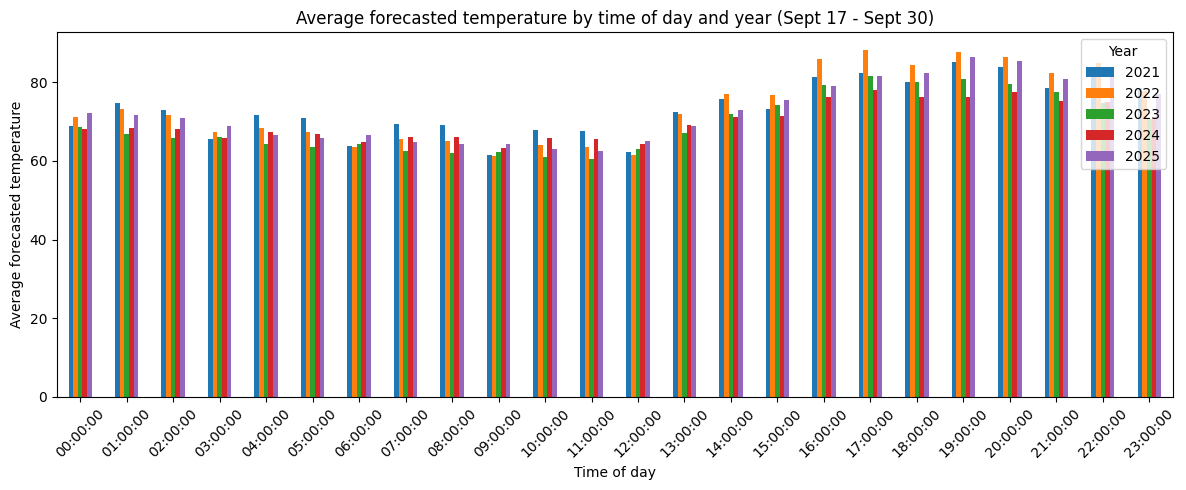

In [116]:
# Group temperature by day and measure average temperature each day
avg_temp = X_train.groupby(["pred_year", "pred_time"], as_index=False)["forecasted_temp"].mean()

print(avg_temp.dtypes)
print(avg_temp.head())

# Reshape so each year becomes its own column
pivot = avg_temp.pivot(index="pred_time", columns="pred_year", values="forecasted_temp")

# Grouped bar chart: one bar per year at each time of day
pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Average forecasted temperature by time of day and year (Sept 17 - Sept 30)")
plt.xlabel("Time of day")
plt.ylabel("Average forecasted temperature")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()